In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('/content/drive/MyDrive/brazil_states_population.csv')
df

,State,Area_km2,Population_2010,Density_2010,Population_2022,Density_2022
0,Acre,164123738,733559,4.47,829780,5.05
1,Amapá,142470762,669526,4.70,774268,5.43
2,Roraima,224273831,450479,2.01,634805,2.83
3,São Paulo,248219481,41262199,166.23,46024937,185.42
4,Minas Gerais,586521121,19597330,33.41,20732660,35.35
5,Rio de Janeiro,43750423,15989929,365.48,16615526,379.78
6,Bahia,564722611,14016906,24.82,14659023,25.96
7,Paraná,199305236,10444526,52.40,11835379,59.38
8,Rio Grande do Sul,281707151,10693929,37.96,11088065,39.36
9,Pernambuco,98068021,8796448,89.70,9051113,92.29


(np.float64(-8468096.613157349),
 np.float64(-3374194.7160243476),
 np.float64(-4224616.917354949),
 np.float64(816744.098119658))

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 48652 (\N{HANGUL SYLLABLE BEU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51656 (\N{HANGUL SYLLABLE JIL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) mis

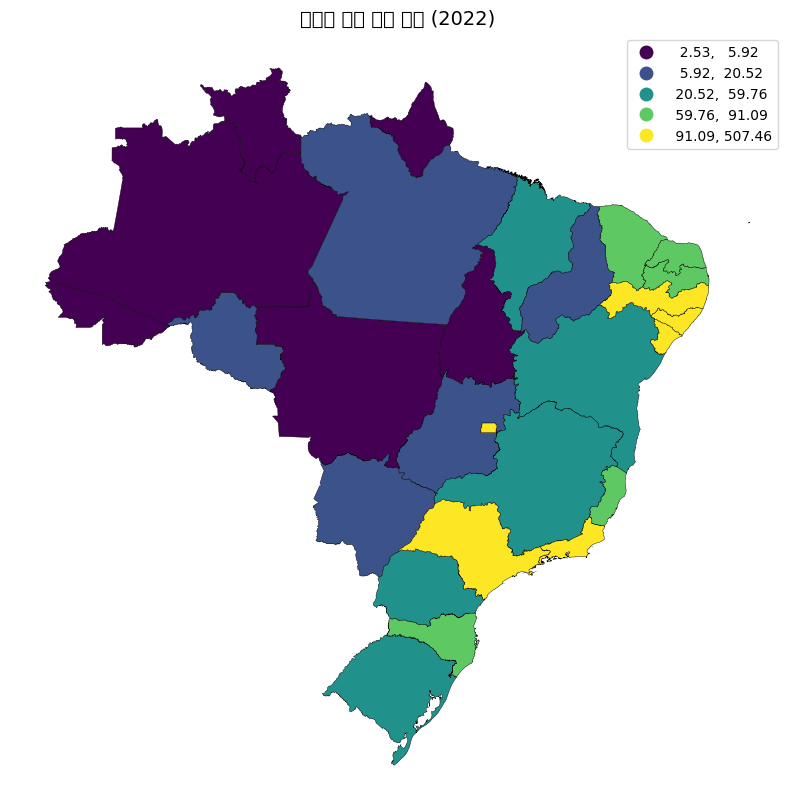

In [5]:
# 필요한 패키지 설치(처음 한 번만)
!pip -q install geopandas mapclassify

import pandas as pd
import geopandas as gpd

# 1) 브라질 주 경계 GeoJSON (URL로 바로 로드)
GEOJSON_URL = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
states = gpd.read_file(GEOJSON_URL)  # 'name' 컬럼에 주 이름 있음

# 2) 주별 인구/밀도 CSV 로드 (경로만 네 환경에 맞게)
CSV_PATH = "/content/drive/MyDrive/brazil_states_population.csv"  # 필요 시 드라이브 경로로 변경
pop = pd.read_csv(CSV_PATH, encoding="utf-8-sig")   # 'State', 'Density_2022' 컬럼 있음

# 3) 조인키 맞추기 (이름 공백/대소문자/악센트 등 최소 정리)
states["name_clean"] = states["name"].str.strip()
pop["State_clean"] = pop["State"].str.strip()

# 4) GeoDataFrame으로 병합
gdf = states.merge(pop, left_on="name_clean", right_on="State_clean", how="left")

# 5) 지도 투영(그리기 편하게; 베이스맵 없으면 생략해도 OK)
gdf = gdf.to_crs(3857)

# 6) 코로플레스(밀도 구간화)
ax = gdf.plot(
    column="Density_2022",
    scheme="Quantiles",  # 분위수 구간
    k=5,                 # 5단계 등급
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    figsize=(10, 10)
)
ax.set_title("브라질 주별 인구 밀도 (2022)", fontsize=14)
ax.axis("off")


In [12]:
# 패키지 설치
!pip -q install geopandas mapclassify contextily geobr

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from geobr import read_municipality            # município 경계
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

# 1) município 경계(2020 기준 전체)
muni = read_municipality(year=2020)            # 'code_muni', 'name_muni', 'abbrev_state' 등 포함 (CRS=EPSG:4674)

# 2) IBGE 2022 município 인구 CSV 불러오기
#    파일 예시 컬럼: code_muni(IBGE 7자리 또는 6~7자리 정수), pop2022(정수)
POP_CSV = "/content/drive/MyDrive/brazil_states_population.csv"   # <-- 여기에 네 파일 경로 지정
pop = pd.read_csv(POP_CSV)

# 3) 조인 준비
# geobr의 code_muni는 정수형(혹은 int64)일 수 있으므로 두 쪽 타입을 맞춰준다.
pop["code_muni"] = pd.to_numeric(pop["code_muni"], errors="coerce").astype("Int64")
muni["code_muni"] = pd.to_numeric(muni["code_muni"], errors="coerce").astype("Int64")

# 4) 병합
gdf = muni.merge(pop, on="code_muni", how="left")

# 5) 면적(km²) 계산 후 밀도 산출
gdf = gdf.to_crs(3857)                                 # 면적 계산용(m 단위)
gdf["area_km2"] = gdf.geometry.area / 1_000_000
gdf["density_2022"] = gdf["pop2022"] / gdf["area_km2"]

# 6) 색/구간 (예시 이미지 톤)
bins = [0, 5, 12, 18, 25, 35, 55, 115, np.inf]
colors = ["#fff7bc","#fee391","#fec44f","#fe9929","#ec7014","#cc4c02","#993404","#662506"]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bins, cmap.N, clip=True)

# 7) 그리기 (폴리곤이 많아 렌더링이 다소 느릴 수 있음)
fig, ax = plt.subplots(figsize=(11, 13))
gdf.plot(column="density_2022", cmap=cmap, norm=norm,
         edgecolor="none", linewidth=0.0, alpha=0.95, ax=ax)

# 8) 베이스맵(선택·고해상도)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=6)

# 9) 범례 생성
import matplotlib.patches as mpatches
handles, labels = [], []
for i in range(len(bins)-1):
    lo, hi = bins[i], bins[i+1]
    lab = f"{int(lo)}+" if np.isinf(hi) else f"{int(lo)}–{int(hi)}"
    handles.append(mpatches.Patch(color=colors[i]))
    labels.append(lab)
leg = ax.legend(handles, labels, title="Habitantes / km² (2022)", loc="lower right")
leg.get_frame().set_edgecolor("gray"); leg.get_frame().set_linewidth(0.6)

ax.set_title("Brasil — Densidade Populacional por Município (2022)", fontsize=15, pad=12)
ax.axis("off")
plt.tight_layout()

# 저장(고해상도)
#plt.savefig("/content/brazil_density_municipios.png", dpi=300, bbox_inches="tight")
plt.show()


KeyError: 'code_muni'